### Import Thư viện


In [45]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import time, os, re, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

import xgboost as xgb
import lightgbm as lgb
import joblib


### Load & EDA


In [46]:
# Load dữ liệu
df = pd.read_csv('creditcard_processed.csv')

# Xử lý các cột lỗi nếu có
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df = df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

# In thông tin cơ bản
print("Data Shape:", df.shape)
print("Class Distribution:\n", df['Class'].value_counts())
print("Fraud Ratio:", sum(df['Class']==1)/len(df) * 100, "%")


Data Shape: (283726, 31)
Class Distribution:
 Class
0    283253
1       473
Name: count, dtype: int64
Fraud Ratio: 0.1667101358352777 %


### Train/Test Split (Original data)
Pipeline sẽ tự scale bên trong, không scale thủ công ở đây để tránh data leakage.


In [47]:
X = df.drop('Class', axis=1)   # Giữ nguyên Time, Amount gốc
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (226980, 30)
X_test shape: (56746, 30)


### Định nghĩa Preprocessor, Samplers, Models


In [ ]:
import os
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

preprocessor = ColumnTransformer([
    ('scaler', RobustScaler(), ['Time', 'Amount'])
], remainder='passthrough')

samplers = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(n_neighbors=5, random_state=42)
}

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        max_depth=None,
        min_samples_split=5, 
        min_samples_leaf=2,
        n_jobs=-1, 
        random_state=42
    ),
    
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, 
        max_depth=6,
        learning_rate=0.05, 
        subsample=0.8, 
        colsample_bytree=0.8,
        scale_pos_weight=1, 
        eval_metric='logloss',
        random_state=42, 
        n_jobs=-1
    ),
    
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, 
        max_depth=6,
        learning_rate=0.05, 
        num_leaves=63,
        subsample=0.8, 
        colsample_bytree=0.8,
        random_state=42, 
        n_jobs=-1, 
        verbose=-1
    )
}

os.makedirs('models', exist_ok=True)
all_results = []


### Vòng lặp chính: Train → Evaluate → Lưu

*LÝ DO DÙNG ImbPipeline*: imblearn pipeline đảm bảo các phương pháp resampling như SMOTE/ADASYN chỉ được apply (fit_resample) vào Dữ Liệu Huấn Luyện (X_train). Khi đánh giá trên X_test (quá trình predict), nó chỉ transform preprocessor và bỏ qua bước resample, ngăn chặn hoàn toàn Data Leakage.



  Random Forest + SMOTE
Train Time : 114.45s
Precision  : 0.91250
Recall     : 0.76842
F1-Score   : 0.83429
ROC-AUC    : 0.96793
PR-AUC     : 0.80482


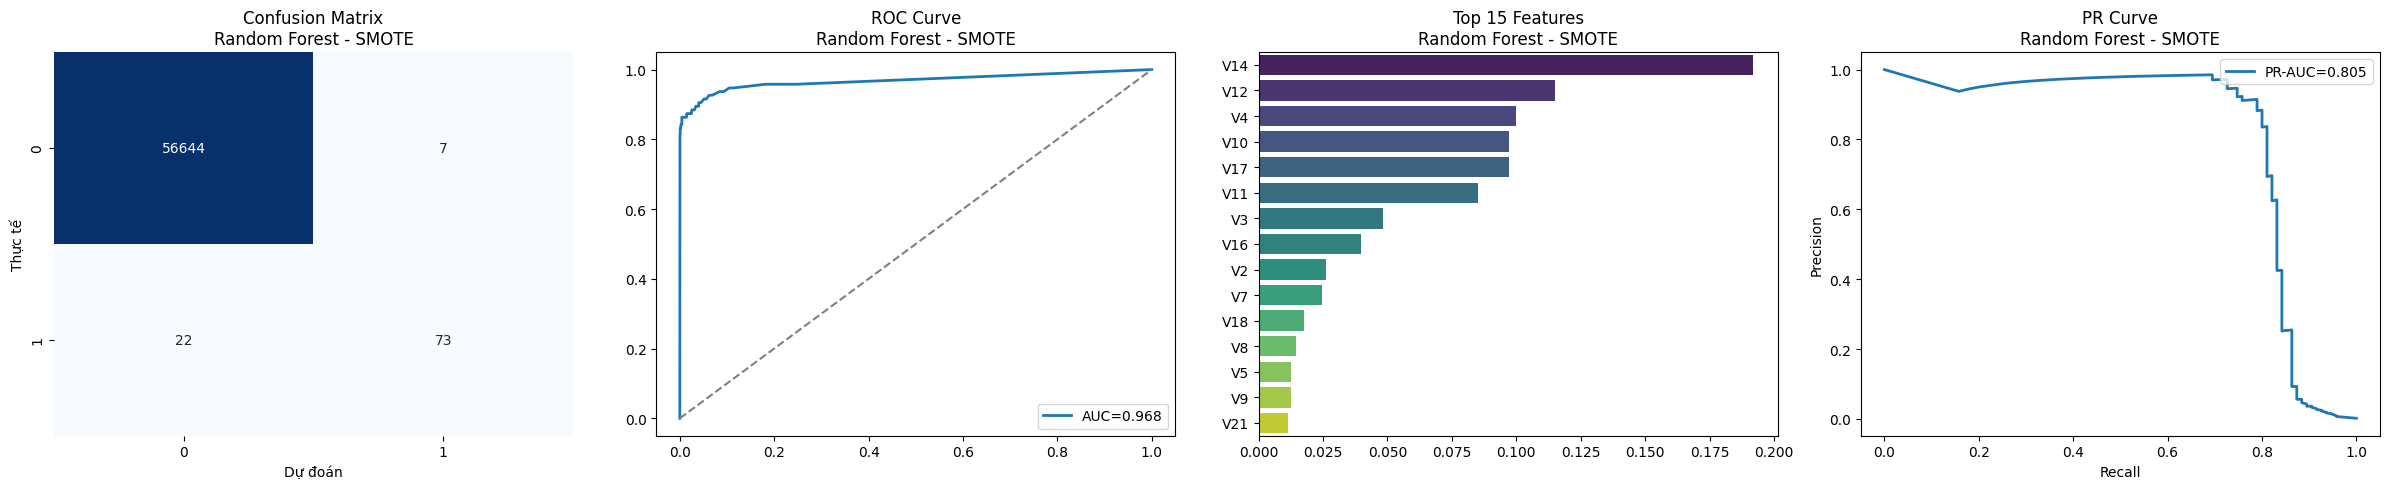

✅ Đã lưu: models/model_random forest_smote.pkl

  XGBoost + SMOTE
Train Time : 6.45s
Precision  : 0.62500
Recall     : 0.78947
F1-Score   : 0.69767
ROC-AUC    : 0.97095
PR-AUC     : 0.79962


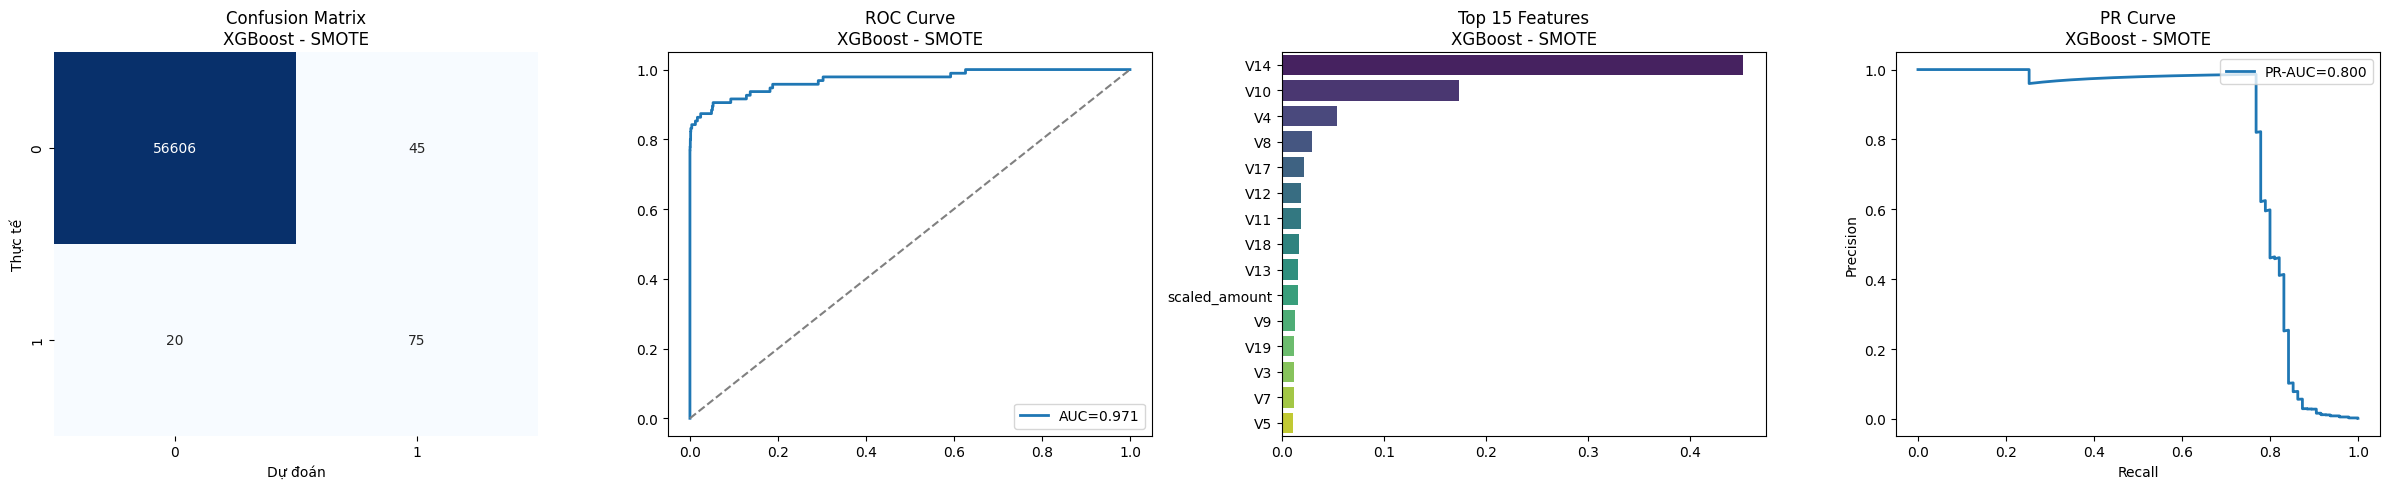

✅ Đã lưu: models/model_xgboost_smote.pkl

  LightGBM + SMOTE
Train Time : 3.88s
Precision  : 0.64957
Recall     : 0.80000
F1-Score   : 0.71698
ROC-AUC    : 0.96746
PR-AUC     : 0.80245


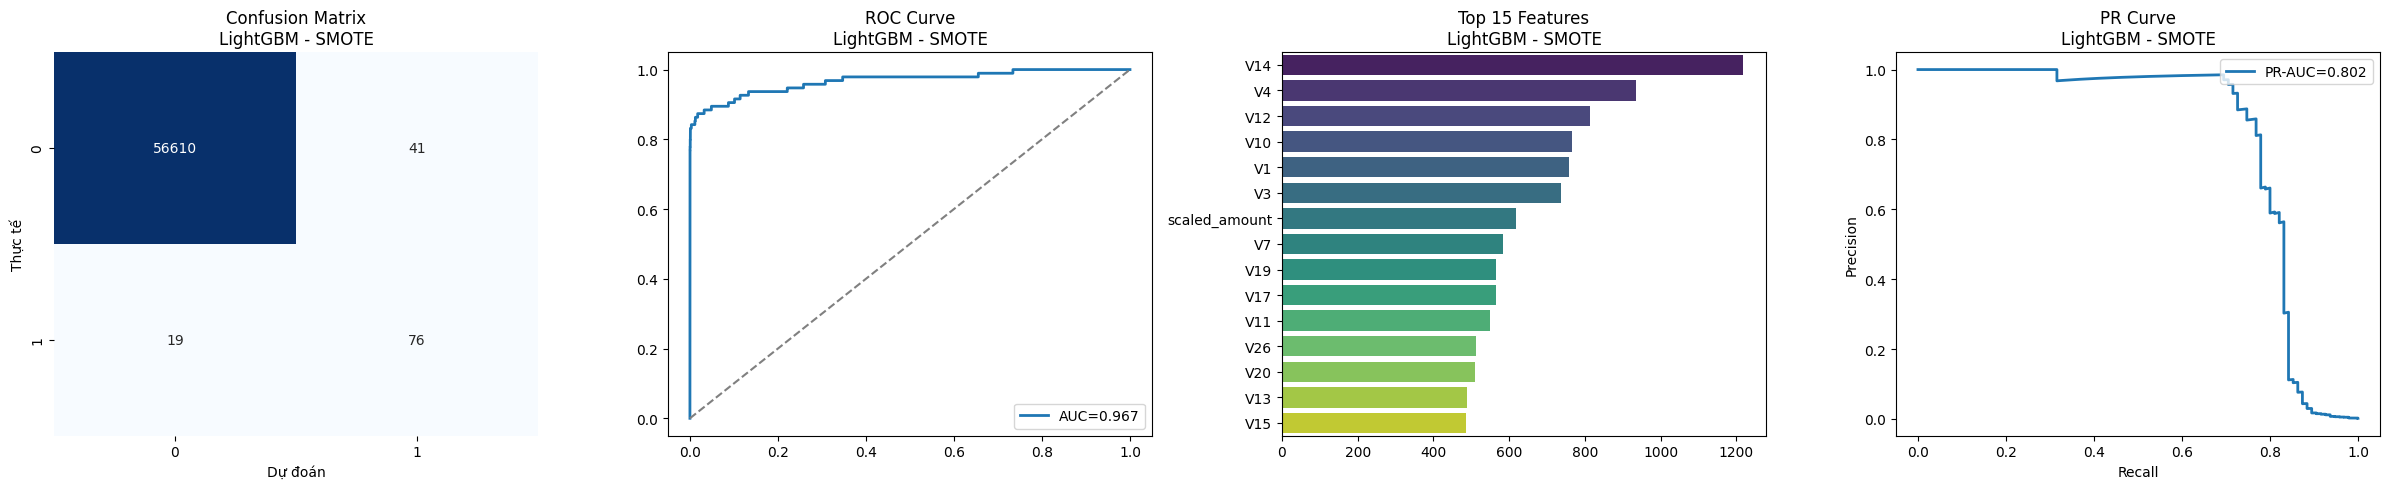

✅ Đã lưu: models/model_lightgbm_smote.pkl

  Random Forest + ADASYN
Train Time : 117.33s
Precision  : 0.90123
Recall     : 0.76842
F1-Score   : 0.82955
ROC-AUC    : 0.96187
PR-AUC     : 0.80230


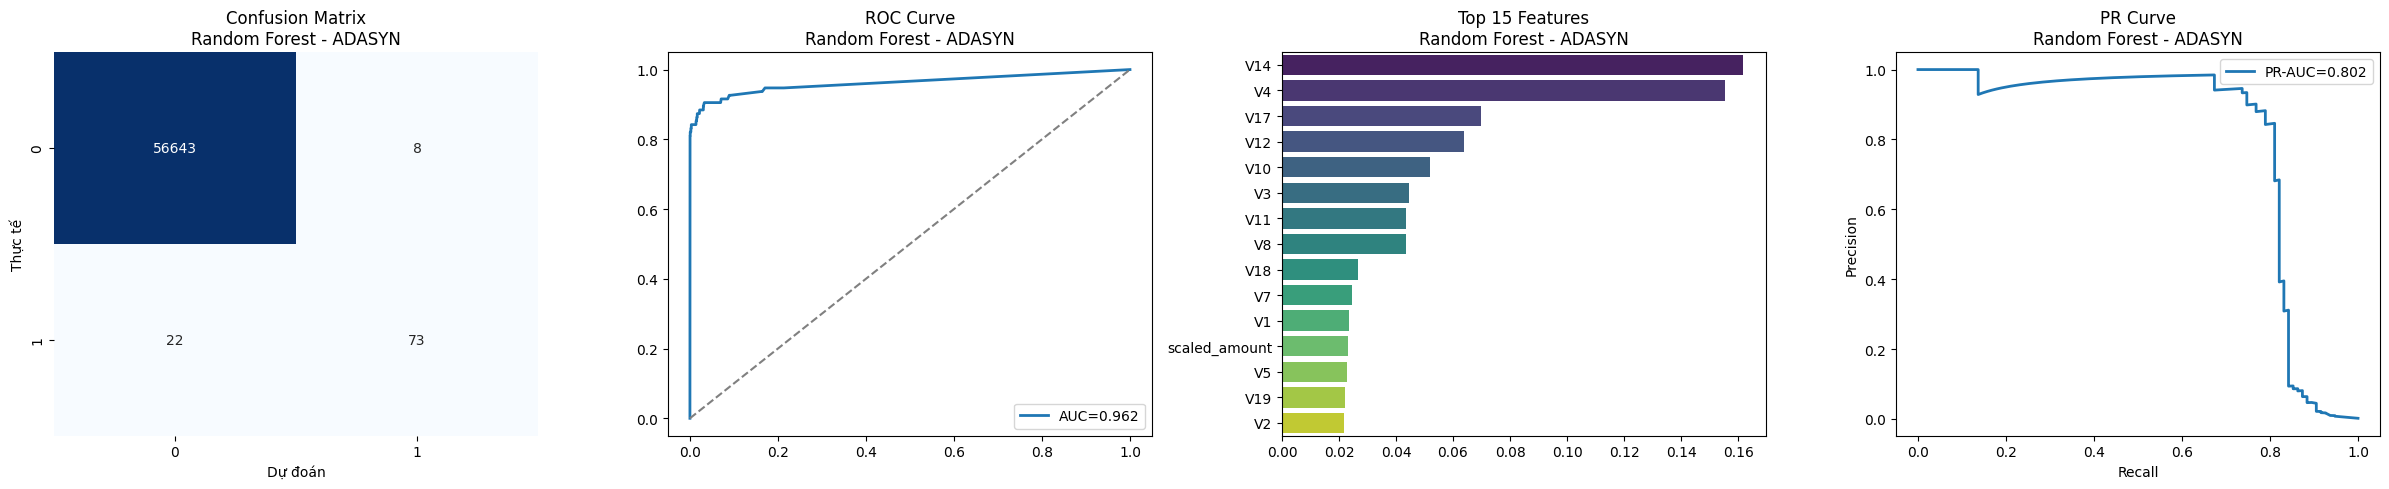

✅ Đã lưu: models/model_random forest_adasyn.pkl

  XGBoost + ADASYN
Train Time : 7.16s
Precision  : 0.50000
Recall     : 0.80000
F1-Score   : 0.61538
ROC-AUC    : 0.96667
PR-AUC     : 0.78218


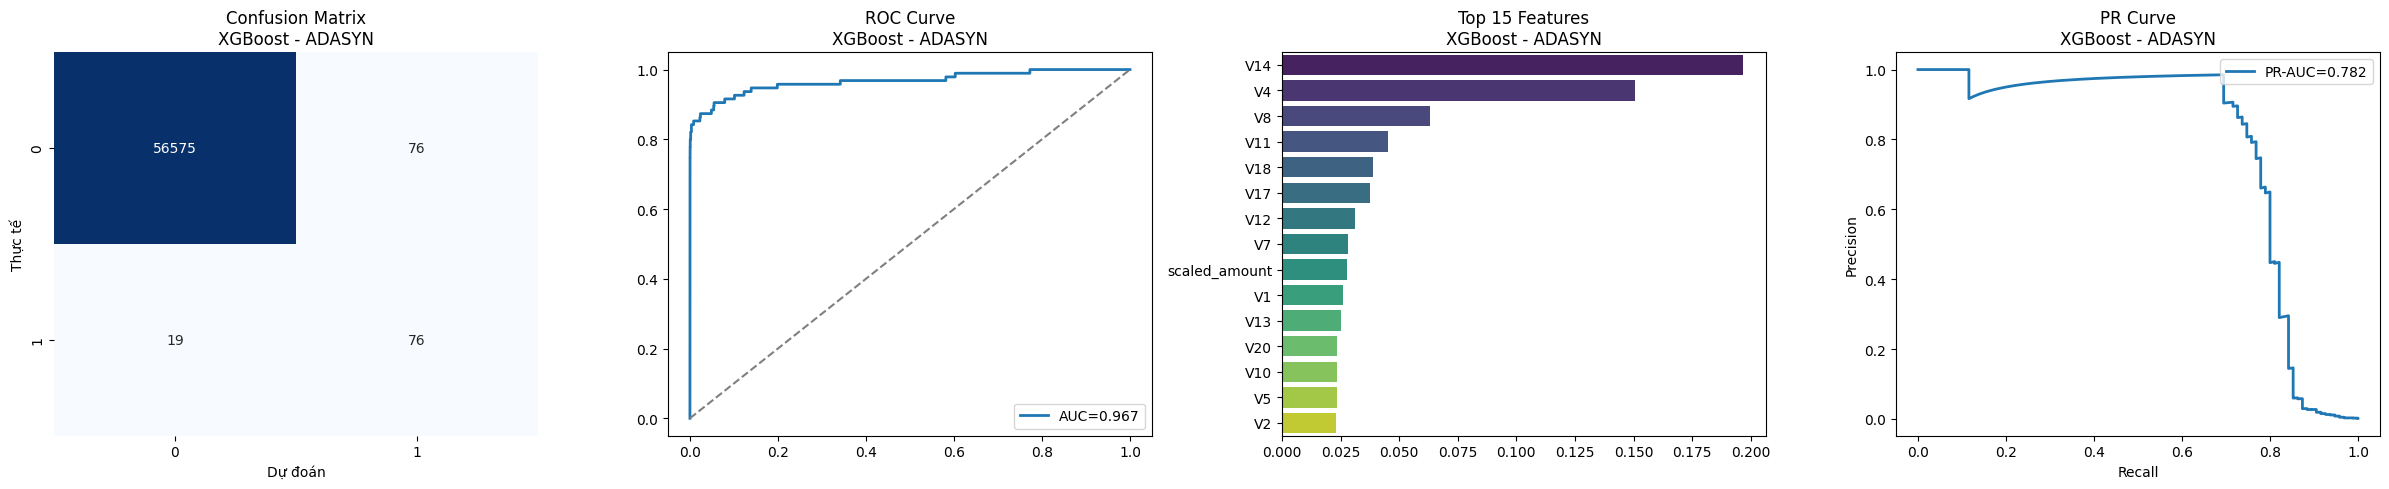

✅ Đã lưu: models/model_xgboost_adasyn.pkl

  LightGBM + ADASYN
Train Time : 4.47s
Precision  : 0.50331
Recall     : 0.80000
F1-Score   : 0.61789
ROC-AUC    : 0.96110
PR-AUC     : 0.77956


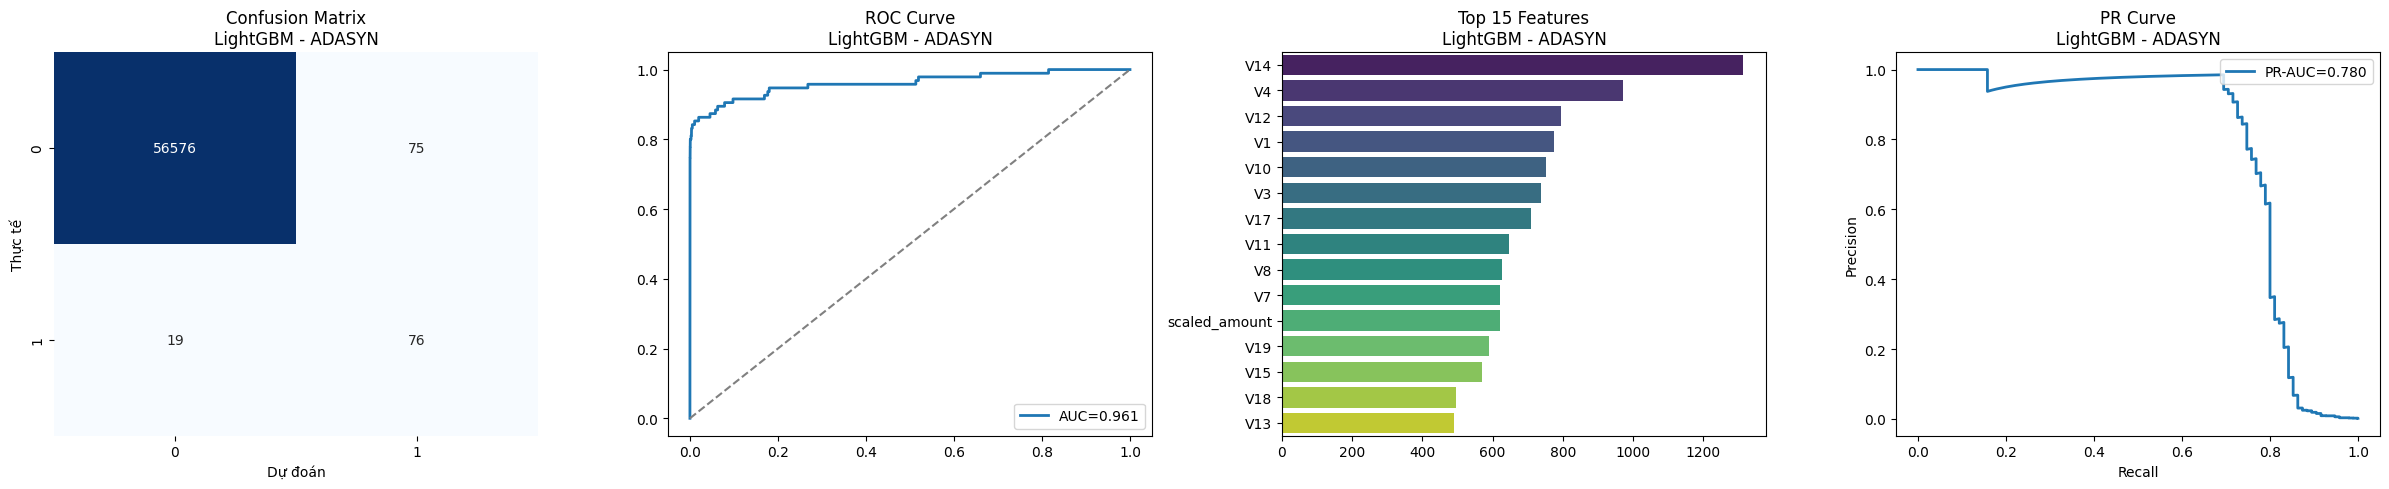

✅ Đã lưu: models/model_lightgbm_adasyn.pkl


In [ ]:
#Duyệt theo dict
for sampler_name, sampler in samplers.items():
    for model_name, classifier in models.items():

        print(f"\n{'='*55}")
        print(f"  {model_name} + {sampler_name}")
        print(f"{'='*55}")

        pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('sampler',      sampler),
            ('classifier',   classifier)
        ])

        t0 = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        prec  = precision_score(y_test, y_pred)
        rec   = recall_score(y_test, y_pred)
        f1    = f1_score(y_test, y_pred)
        roc   = roc_auc_score(y_test, y_prob)
        pr    = average_precision_score(y_test, y_prob)

        print(f"Train Time : {train_time:.2f}s")
        print(f"Precision  : {prec:.5f}")
        print(f"Recall     : {rec:.5f}")
        print(f"F1-Score   : {f1:.5f}")
        print(f"ROC-AUC    : {roc:.5f}")
        print(f"PR-AUC     : {pr:.5f}")

        all_results.append({
            'model': model_name.lower(), 'method': sampler_name.lower(),
            'model_label': {'rf': 'Random Forest', 'xgb': 'XGBoost', 'lgbm': 'LightGBM'}.get(model_name.lower(), model_name),
            'method_label': sampler_name,
            'train_time': round(train_time, 2),
            'precision': prec, 'recall': rec, 'f1': f1,
            'roc_auc': roc, 'pr_auc': pr
        })

        # Vẽ biểu đồ cho pipeline này
        fig, axes = plt.subplots(1, 4, figsize=(24, 5))

        # 1. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    cbar=False, ax=axes[0])
        axes[0].set_title(f'Confusion Matrix\n{model_name} - {sampler_name}')
        axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        # Lấy danh sách xác suất gian lận mà model trả về làm các ngưỡng threshold
        # để vẽ các điểm trên đồ thị ROC-AUC sẽ lấy các xác suất đã trả về làm ngưỡng
        # để dự báo ra các giao dịch gian lận từ đó tính các TPR, FPR...
        axes[1].plot(fpr, tpr, lw=2, label=f'AUC={roc:.3f}')
        axes[1].plot([0,1],[0,1],'--', color='grey')
        #model random y = x threshold = 0.5
        axes[1].set_title(f'ROC Curve\n{model_name} - {sampler_name}')
        axes[1].legend(loc='lower right')

        # 3. Feature Importance
        clf_step = pipeline.named_steps['classifier']
        importances = clf_step.feature_importances_
        # Lấy tên feature sau khi qua ColumnTransformer
        num_features = len(X_train.columns)
        feature_names = (
            ['scaled_time', 'scaled_amount'] +
            [c for c in X_train.columns if c not in ['Time', 'Amount']]
        )
        #list slicing duyệt ngược từ cuối và lấy 15 features quan trọng nhất
        indices = np.argsort(importances)[::-1][:15]
        sns.barplot(x=importances[indices],
                    y=[feature_names[i] for i in indices],
                    ax=axes[2], palette="viridis")
        axes[2].set_title(f'Top 15 Features\n{model_name} - {sampler_name}')

        # 4. PR Curve
        prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
        axes[3].plot(rec_vals, prec_vals, lw=2, label=f'PR-AUC={pr:.3f}')
        axes[3].set_title(f'PR Curve\n{model_name} - {sampler_name}')
        axes[3].set_xlabel('Recall'); axes[3].set_ylabel('Precision')
        axes[3].legend(loc='upper right')

        plt.tight_layout()
        plt.show()

        # ── LƯU ĐÚNG PIPELINE ĐÃ EVALUATE ──
        save_path = f'models/model_{model_name.lower()}_{sampler_name.lower()}.pkl'
        joblib.dump(pipeline, save_path)
        print(f"✅ Đã lưu: {save_path}")


### Bảng tổng kết & So sánh


In [50]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('pr_auc', ascending=False)
print("\n=== BẢNG TỔNG KẾT (sắp xếp theo PR-AUC) ===")
print(results_df[['model_label', 'method_label', 'train_time', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']].to_string(index=False))

# Best model
best = results_df.iloc[0]
print(f"\n🏆 Best: {best['model_label']} + {best['method_label']}")
print(f"   PR-AUC={best['pr_auc']:.4f} | F1={best['f1']:.4f} | Recall={best['recall']:.4f}")

# Cập nhật performance_metrics.csv để app Streamlit có thể tải
results_df.to_csv('models/performance_metrics.csv', index=False)
print(f"\nĐã lưu kết quả vào models/performance_metrics.csv")



=== BẢNG TỔNG KẾT (sắp xếp theo PR-AUC) ===
  model_label method_label  train_time  precision   recall       f1  roc_auc   pr_auc
Random Forest        SMOTE      114.45   0.912500 0.768421 0.834286 0.967928 0.804816
     LightGBM        SMOTE        3.88   0.649573 0.800000 0.716981 0.967461 0.802447
Random Forest       ADASYN      117.33   0.901235 0.768421 0.829545 0.961871 0.802304
      XGBoost        SMOTE        6.45   0.625000 0.789474 0.697674 0.970948 0.799620
      XGBoost       ADASYN        7.16   0.500000 0.800000 0.615385 0.966667 0.782181
     LightGBM       ADASYN        4.47   0.503311 0.800000 0.617886 0.961100 0.779565

🏆 Best: Random Forest + SMOTE
   PR-AUC=0.8048 | F1=0.8343 | Recall=0.7684

Đã lưu kết quả vào models/performance_metrics.csv


### Biểu đồ so sánh tổng hợp


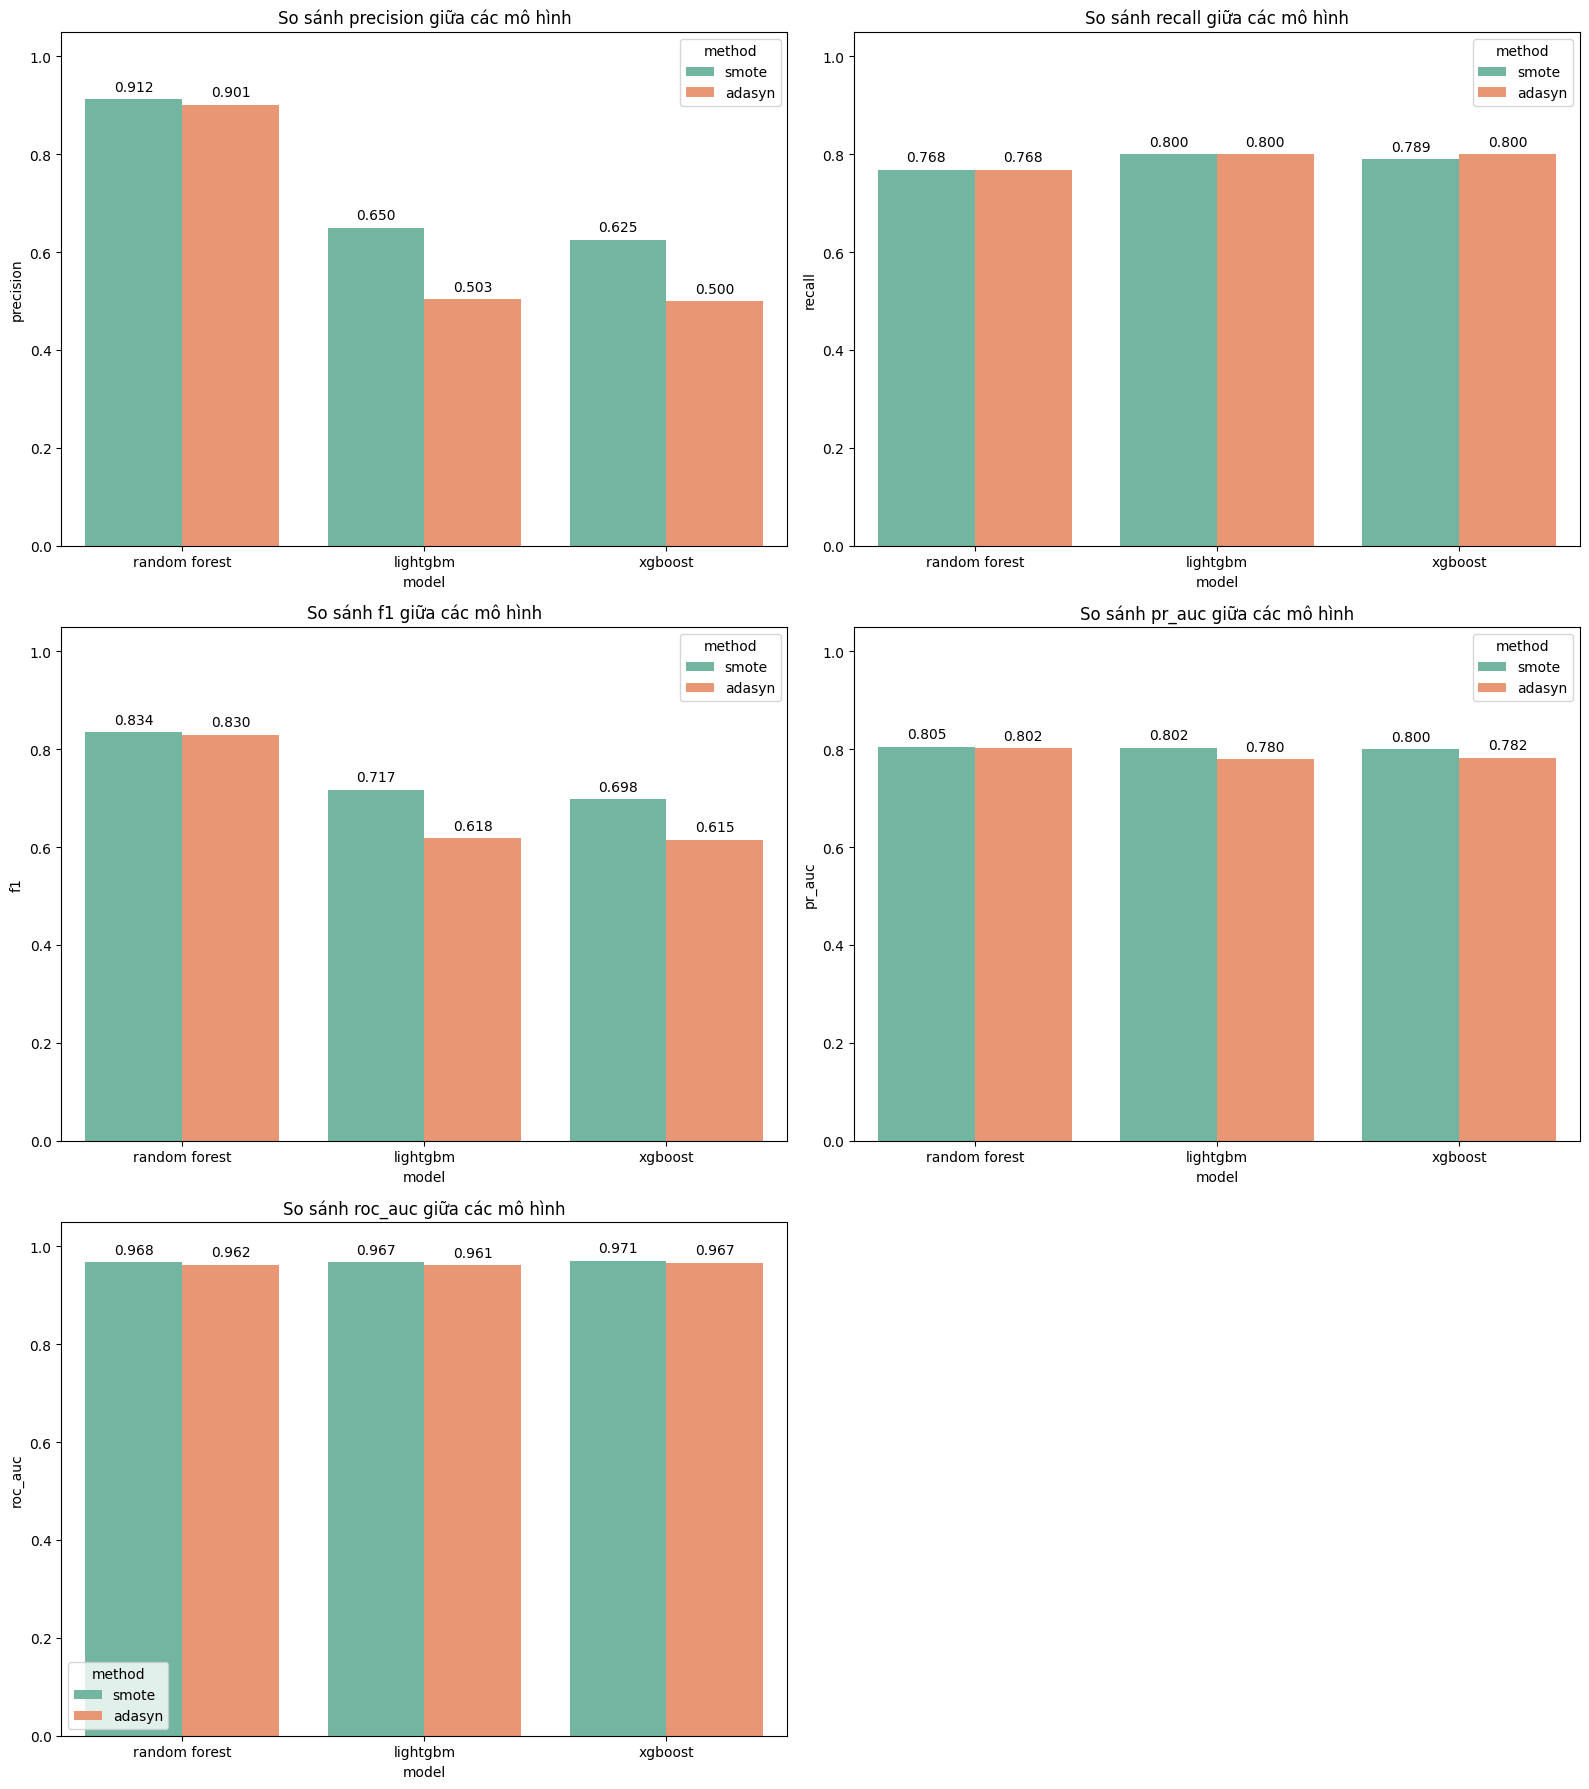

In [51]:
metrics_to_plot = ['precision', 'recall', 'f1', 'pr_auc', 'roc_auc']
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=results_df, x='model', y=metric, hue='method', ax=axes[i], palette='Set2')
    axes[i].set_title(f'So sánh {metric} giữa các mô hình')
    axes[i].set_ylim(0, 1.05)
    
    # Thêm text giá trị lên trên mỗi thanh
    for p in axes[i].patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            axes[i].annotate(format(height, '.3f'), 
                             (p.get_x() + p.get_width() / 2., height), 
                             ha = 'center', va = 'center', 
                             xytext = (0, 9), 
                             textcoords = 'offset points')

# Ẩn ô cuối cùng
axes[5].axis('off')
plt.tight_layout()
plt.show()
